In [32]:
import ee
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

ee.Initialize(project="sentinel-487715")

# Ghana boundary
ghana = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
    .filter(ee.Filter.eq("country_na", "Ghana")) \
    .geometry()

# Load roads from GEE asset (replace with your asset ID)
roads = ee.FeatureCollection("projects/sentinel-487715/assets/ghana_roads")


# Sample 5 features and print their properties
samples = roads.limit(5).getInfo()
for f in samples["features"]:
    print(f["properties"])

# total number of roads
total = roads.size().getInfo()
print("Total roads:", total)


{'bridge': 'F', 'code': 5112, 'fclass': 'trunk', 'layer': 0, 'maxspeed': 0, 'name': 'Dr. Obour Boffah Link', 'oneway': 'B', 'osm_id': '520162721', 'ref': 'N12', 'tunnel': 'F'}
{'bridge': 'F', 'code': 5112, 'fclass': 'trunk', 'layer': 0, 'maxspeed': 0, 'name': 'B. K. Adama Street', 'oneway': 'F', 'osm_id': '574240962', 'ref': 'N12', 'tunnel': 'F'}
{'bridge': 'F', 'code': 5112, 'fclass': 'trunk', 'layer': 0, 'maxspeed': 0, 'name': 'Airport Road', 'oneway': 'F', 'osm_id': '574240965', 'ref': 'N12', 'tunnel': 'F'}
{'bridge': 'F', 'code': 5112, 'fclass': 'trunk', 'layer': 0, 'maxspeed': 0, 'name': 'Airport Road', 'oneway': 'F', 'osm_id': '574240966', 'ref': 'N12', 'tunnel': 'F'}
{'bridge': 'F', 'code': 5112, 'fclass': 'trunk', 'layer': 0, 'maxspeed': 0, 'name': 'B. K. Adama Street', 'oneway': 'F', 'osm_id': '574240968', 'ref': 'N12', 'tunnel': 'F'}
Total roads: 372639


In [16]:
# counts per fclass
hist = roads.aggregate_histogram("fclass").getInfo()

# print as a simple table
df = pd.DataFrame(
    [{"fclass": k, "count": v} for k, v in hist.items()]
).sort_values("count", ascending=False)

print(df)


            fclass   count
11     residential  258612
14         service   36318
26    unclassified   23166
7             path   19722
18           track   17083
16        tertiary    4929
3          footway    4657
12       secondary    2516
24           trunk    1887
9          primary    1676
25      trunk_link     480
10    primary_link     299
13  secondary_link     229
4    living_street     193
15           steps     172
8       pedestrian     116
22    track_grade4     112
21    track_grade3     110
17   tertiary_link      93
23    track_grade5      60
6    motorway_link      60
5         motorway      43
20    track_grade2      38
27         unknown      32
2         cycleway      18
0        bridleway      12
19    track_grade1       4
1           busway       2


In [33]:
def count_missing(field):
    # missing if null or empty string
    missing = roads.filter(ee.Filter.Or(
        ee.Filter.eq(field, None),
        ee.Filter.eq(field, "")
    )).size().getInfo()
    return missing

def count_zero(field):
    return roads.filter(ee.Filter.eq(field, 0)).size().getInfo()

print("\nMissing attribute counts:")
for f in ["name", "ref", "maxspeed", "oneway", "bridge", "tunnel"]:
    print(f"{f}: {count_missing(f)}")

print("\nMaxspeed == 0:", count_zero("maxspeed"))

print("\nValue counts (top categories):")
print("fclass:", roads.aggregate_histogram("fclass").getInfo())
print("oneway:", roads.aggregate_histogram("oneway").getInfo())
print("bridge:", roads.aggregate_histogram("bridge").getInfo())
print("tunnel:", roads.aggregate_histogram("tunnel").getInfo())


Missing attribute counts:
name: 358145
ref: 369190
maxspeed: 0
oneway: 0
bridge: 0
tunnel: 0

Maxspeed == 0: 347377

Value counts (top categories):
fclass: {'bridleway': 12, 'busway': 2, 'cycleway': 18, 'footway': 4657, 'living_street': 193, 'motorway': 43, 'motorway_link': 60, 'path': 19722, 'pedestrian': 116, 'primary': 1676, 'primary_link': 299, 'residential': 258612, 'secondary': 2516, 'secondary_link': 229, 'service': 36318, 'steps': 172, 'tertiary': 4929, 'tertiary_link': 93, 'track': 17083, 'track_grade1': 4, 'track_grade2': 38, 'track_grade3': 110, 'track_grade4': 112, 'track_grade5': 60, 'trunk': 1887, 'trunk_link': 480, 'unclassified': 23166, 'unknown': 32}
oneway: {'B': 365419, 'F': 7219, 'T': 1}
bridge: {'F': 370376, 'T': 2263}
tunnel: {'F': 372441, 'T': 198}


In [34]:
keep_classes = [
    "residential","service","unclassified","primary","secondary","motorway",
    "trunk","service","tertiary",
    "primary_link","tertiary_link","secondary_link","trunk_link","motorway_link"
]

roads = roads.filter(ee.Filter.inList("fclass", keep_classes))

# add length in meters
roads_len = roads.map(lambda f: f.set("length_m", f.length()))

# mean + min + max + stdDev grouped by fclass
reducer = (ee.Reducer.mean()
           .combine(ee.Reducer.min(), sharedInputs=True)
           .combine(ee.Reducer.max(), sharedInputs=True)
           .combine(ee.Reducer.stdDev(), sharedInputs=True)
           .group(groupField=0, groupName="fclass"))

stats = roads_len.reduceColumns(
    reducer=reducer,
    selectors=["fclass", "length_m"]
).get("groups").getInfo()

df_len = pd.DataFrame(stats).rename(columns={
    "mean": "mean_length_m",
    "min": "min_length_m",
    "max": "max_length_m",
    "stdDev": "std_length_m"
})
df_len


,fclass,max_length_m,mean_length_m,min_length_m,std_length_m
0,motorway,9972.491482,941.720976,13.297619,1875.065973
1,motorway_link,779.656495,212.753618,7.805990,199.997870
2,primary,67370.672062,2370.218777,2.206095,6120.756621
3,primary_link,389.922544,45.912501,4.417107,57.521767
4,residential,21585.632047,211.902126,0.493104,230.571989
5,secondary,67596.990503,2670.247177,1.479316,6542.838276
6,secondary_link,544.951102,54.802080,5.038004,69.915311
7,service,16386.172021,117.100412,0.000000,241.842007
8,tertiary,67409.194724,2901.659119,0.986211,5869.769975
9,tertiary_link,85.718112,27.347687,8.483443,16.459151


In [36]:
# filter out zero maxspeed
roads_speed = roads.filter(ee.Filter.gt("maxspeed", 0))

# mean + stdDev grouped by fclass
reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True) \
    .group(groupField=0, groupName="fclass")

stats = roads_speed.reduceColumns(
    reducer=reducer,
    selectors=["fclass", "maxspeed"]
).get("groups").getInfo()

df_speed = pd.DataFrame(stats).rename(columns={"mean":"mean_speed", "stdDev":"std_speed"})

# total count per fclass (all roads)
total_hist = roads.aggregate_histogram("fclass").getInfo()
df_total = pd.DataFrame(
    [{"fclass": k, "total_count": v} for k, v in total_hist.items()]
)

# non-zero maxspeed count per fclass
nz_hist = roads_speed.aggregate_histogram("fclass").getInfo()
df_nz = pd.DataFrame(
    [{"fclass": k, "nonzero_speed_count": v} for k, v in nz_hist.items()]
)

# merge + percentage
df_speed = df_speed.merge(df_total, on="fclass", how="left").merge(df_nz, on="fclass", how="left").fillna(0)
df_speed["nonzero_speed_count"] = df_speed["nonzero_speed_count"].astype(int)
df_speed["pct_nonzero_speed"] = (df_speed["nonzero_speed_count"] / df_speed["total_count"] * 100)

df_speed.sort_values("pct_nonzero_speed", ascending=False)


,fclass,mean_speed,std_speed,total_count,nonzero_speed_count,pct_nonzero_speed
0,motorway,96.923077,7.216024,43,39,90.697674
3,primary_link,45.312500,8.563869,299,128,42.809365
2,primary,49.256329,6.383136,1676,632,37.708831
6,secondary_link,43.924051,9.732852,229,79,34.497817
5,secondary,47.353690,8.552761,2516,786,31.240064
11,trunk_link,46.449275,10.618600,480,138,28.750000
8,tertiary,42.663185,10.232317,4929,1149,23.311016
10,trunk,51.531323,9.238943,1887,431,22.840488
7,service,30.194194,2.640448,36318,7750,21.339281
1,motorway_link,54.545455,9.875255,60,11,18.333333


In [30]:
# spot check some lengths to find OSM IDs

def find_osm_id(fclass, target_len, tol=0.001, limit=5):
    fc = roads_len.filter(ee.Filter.eq("fclass", fclass)) \
                  .filter(ee.Filter.gte("length_m", target_len - tol)) \
                  .filter(ee.Filter.lte("length_m", target_len + tol)) \
                  .limit(limit)
    return fc.getInfo()["features"]

# service length 0
print("Service length 0:")
print(find_osm_id("service", 0.0, tol=0.0001))

# trunk length 1.778943
print("Trunk length 1.778943:")
print(find_osm_id("trunk", 1.778943, tol=0.0001))

# unclassified max length 72623.820617
print("Unclassified length 72623.820617:")
print(find_osm_id("unclassified", 72623.820617, tol=0.01))


Service length 0:
[{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [0.46989560991107326, 6.5919738102290575]}, 'id': '00050000000000004244', 'properties': {'bridge': 'F', 'code': 5141, 'fclass': 'service', 'layer': 0, 'length_m': 0, 'maxspeed': 0, 'name': '', 'oneway': 'F', 'osm_id': '1478500297', 'ref': '', 'tunnel': 'T'}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [0.4698733144058059, 6.591947055622737]}, 'id': '00050000000000004248', 'properties': {'bridge': 'F', 'code': 5141, 'fclass': 'service', 'layer': 0, 'length_m': 0, 'maxspeed': 0, 'name': '', 'oneway': 'F', 'osm_id': '1478500301', 'ref': '', 'tunnel': 'T'}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [0.4698911508100196, 6.591969351128004]}, 'id': '0005000000000000424b', 'properties': {'bridge': 'F', 'code': 5141, 'fclass': 'service', 'layer': 0, 'length_m': 0, 'maxspeed': 0, 'name': '', 'oneway': 'F', 'osm_id': '1478543207', 'ref': '', 'tunnel': 'T'}}, {'type': '

In [51]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import networkx as nx


# Topological analysis of unclassified roads
# project for meters

roads = gpd.read_file("/Users/miranda/Documents/GitHub/Sentinel-FYP/data/gis_osm_roads_free_1.shp")
roads_m = roads.to_crs("EPSG:32630")

In [44]:
# sample 5k unclassified roads
sample_uncl = roads_m[roads_m["fclass"]=="unclassified"].sample(10000, random_state=0)
cls = roads_m[roads_m["fclass"]!="unclassified"]

# endpoints
def endpoints(geom):
    coords = list(geom.coords)
    return Point(coords[0]), Point(coords[-1])

roads_m["start_pt"] = roads_m.geometry.apply(lambda g: endpoints(g)[0])
roads_m["end_pt"] = roads_m.geometry.apply(lambda g: endpoints(g)[1])

sindex = roads_m.sindex
TOL = 5  # meters

def neighbors_for_idx(idx):
    row = roads_m.loc[idx]
    pts = [row["start_pt"], row["end_pt"]]
    neigh = set()
    for pt in pts:
        buf = pt.buffer(TOL)
        cand = roads_m.iloc[list(sindex.intersection(buf.bounds))]
        cand = cand[cand.geometry.distance(pt) <= TOL]
        for j in cand.index:
            if j != idx:
                neigh.add(j)
    return neigh

# dominant neighbor class for each sampled unclassified road
results = []
for idx in sample_uncl.index:
    neigh = list(neighbors_for_idx(idx))
    classes = roads_m.loc[neigh, "fclass"].dropna().tolist()
    if not classes:
        results.append("none")
    else:
        vals, counts = np.unique(classes, return_counts=True)
        results.append(vals[counts.argmax()])

summary = pd.Series(results).value_counts().reset_index()
summary.columns = ["neighbor_class", "count"]
summary["percent"] = (summary["count"]/summary["count"].sum()*100).round(2)

summary

,neighbor_class,count,percent
0,unclassified,5169,51.69
1,residential,1566,15.66
2,tertiary,1231,12.31
3,secondary,624,6.24
4,primary,466,4.66
5,trunk,368,3.68
6,track,195,1.95
7,path,155,1.55
8,none,131,1.31
9,service,54,0.54


In [ ]:
# SENTINEL ANALYSIS (balanced sample per class)

import ee, pandas as pd
import matplotlib.pyplot as plt
ee.Initialize(project="sentinel-487715")

ghana = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
    .filter(ee.Filter.eq("country_na", "Ghana")) \
    .geometry()

roads = ee.FeatureCollection("projects/sentinel-487715/assets/ghana_roads")

# Sentinel-2 composite (2023)
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(ghana)
      .filterDate("2023-01-01", "2023-12-31")
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
      .select(["B2","B3","B4","B8","B11","B12"])
      .median())

# Indices
ndvi = s2.normalizedDifference(["B8","B4"]).rename("NDVI")
ndmi = s2.normalizedDifference(["B8","B11"]).rename("NDMI")
ndbi = s2.normalizedDifference(["B11","B8"]).rename("NDBI")
ndwi = s2.normalizedDifference(["B3","B8"]).rename("NDWI")
bsi = (s2.select("B11").add(s2.select("B4"))
       .subtract(s2.select("B8").add(s2.select("B2")))
       .divide(s2.select("B11").add(s2.select("B4"))
               .add(s2.select("B8")).add(s2.select("B2")))
       .rename("BSI"))

img = s2.addBands([ndvi, ndmi, ndbi, ndwi, bsi])

# Balanced sample: 50 per class
classes = ["residential","tertiary","secondary","primary","unclassified","trunk"]
N = 50

def sample_class(fc, cls, n):
    return (fc.filter(ee.Filter.eq("fclass", cls))
              .randomColumn("rand")
              .sort("rand")
              .limit(n))

sample_roads = ee.FeatureCollection([])
for cls in classes:
    sample_roads = sample_roads.merge(sample_class(roads, cls, N))

# Use centroids for faster sampling
sample_pts = sample_roads.map(lambda f: f.setGeometry(f.geometry().centroid()))

# Sample Sentinel values
sampled = img.sampleRegions(
    collection=sample_pts,
    scale=30,
    geometries=False
)

info = sampled.getInfo()
rows = [f["properties"] for f in info["features"]]
df = pd.DataFrame(rows)

df["fclass"].value_counts()




,B11,B12,B2,B3,B4,B8,BSI,NDBI,NDMI,NDVI,...,code,fclass,layer,maxspeed,name,oneway,osm_id,rand,ref,tunnel
2,3148.0,2817.0,984.0,1338.0,1795.0,2142.0,0.225183,0.190170,-0.190170,0.088138,...,5122,residential,0,0,,B,622578465,0.000004,,F
3,3552.0,3240.5,1201.5,1548.5,2055.5,2305.5,0.230457,0.212804,-0.212804,0.057326,...,5115,tertiary,0,0,,B,491162211,0.000008,,F
4,3302.0,2699.0,1237.0,1480.0,1709.0,2631.0,0.128731,0.113096,-0.113096,0.212442,...,5122,residential,0,0,,B,566462036,0.000014,,F
5,3186.0,2997.5,957.5,1237.0,1914.0,2163.5,0.240725,0.191139,-0.191139,0.061189,...,5122,residential,0,0,,B,321710885,0.000018,,F
7,2586.0,2032.5,774.0,1019.5,1147.0,2392.5,0.082107,0.038867,-0.038867,0.351886,...,5122,residential,0,0,,B,615799254,0.000019,,F


**Sentinel‑2 Features**

- **NDVI** — Vegetation greenness; higher values indicate more vegetation.
- **NDMI** — Moisture content; higher values indicate wetter vegetation/soil.
- **NDBI** — Built‑up index; higher values indicate more urban/impervious surfaces.
- **NDWI** — Water/wetness index; higher values indicate more water or wet surfaces.
- **BSI** — Bare Soil Index; higher values indicate exposed soil or bare ground.

**Sentinel‑2 Bands**

- **B2 (Blue)** — Sensitive to haze, water, and atmosphere.
- **B3 (Green)** — Vegetation vigor, water, and urban surfaces.
- **B4 (Red)** — Vegetation absorption; used in NDVI.
- **B8 (NIR)** — Vegetation reflectance and biomass.
- **B11 (SWIR1)** — Soil/moisture and built materials.
- **B12 (SWIR2)** — Moisture, burn scars, and soil discrimination.


In [64]:
summary = df.groupby("fclass")[["NDVI","NDMI","NDBI","NDWI","BSI"]].mean().round(3)
summary


,NDVI,NDMI,NDBI,NDWI,BSI
fclass,,,,,
residential,0.274,-0.094,0.094,-0.365,0.134
secondary,0.227,-0.176,0.176,-0.325,0.188
tertiary,0.156,-0.124,0.124,-0.239,0.141
unclassified,0.322,-0.060,0.060,-0.418,0.109


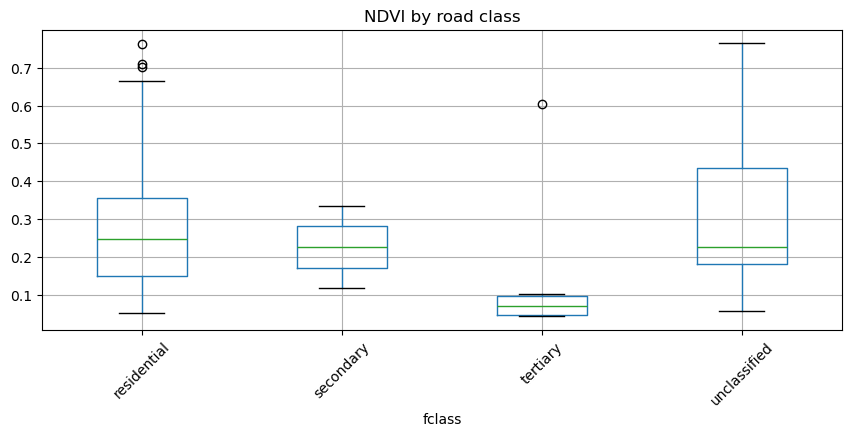

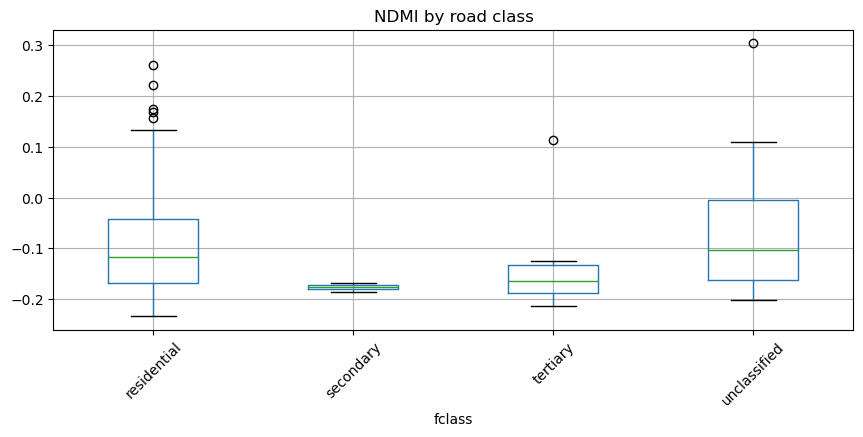

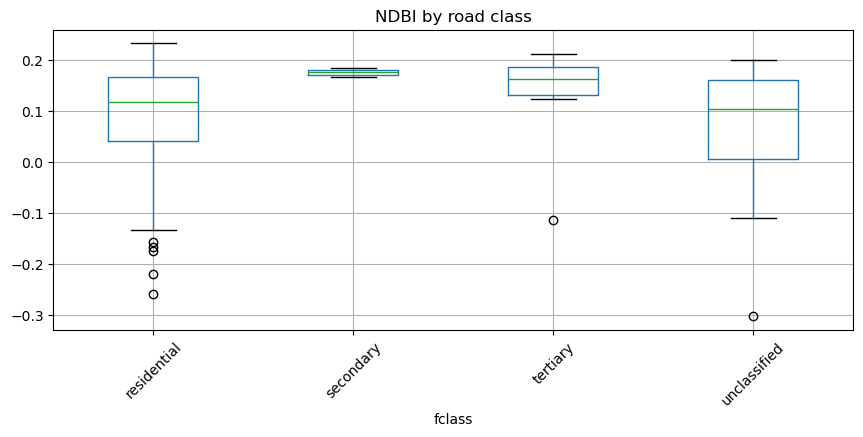

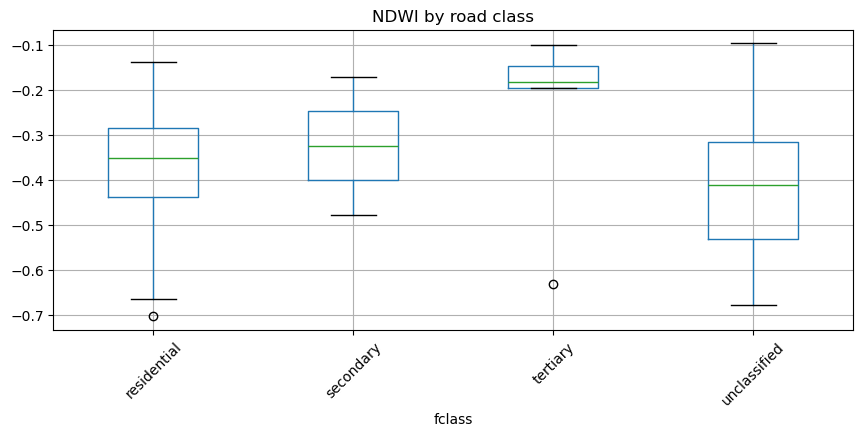

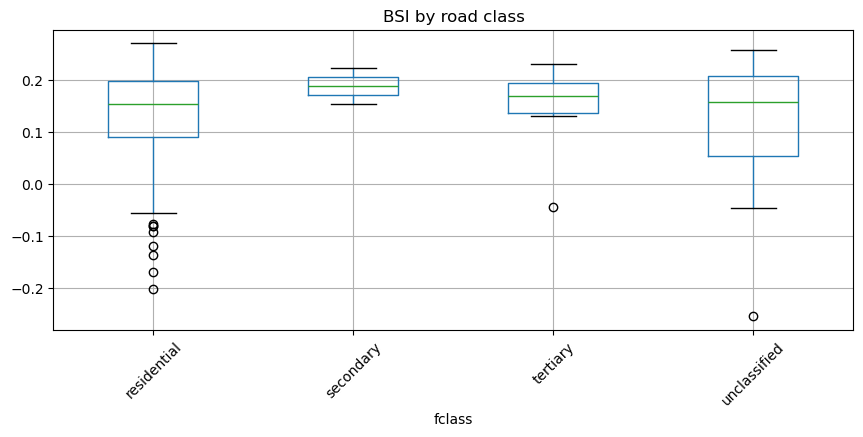

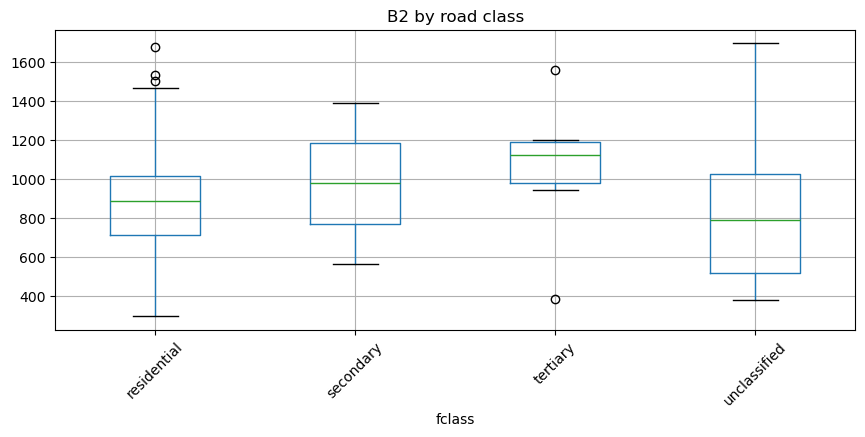

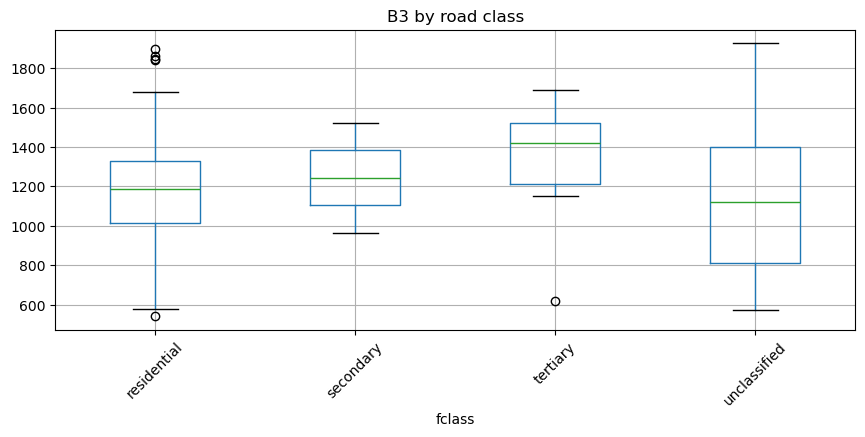

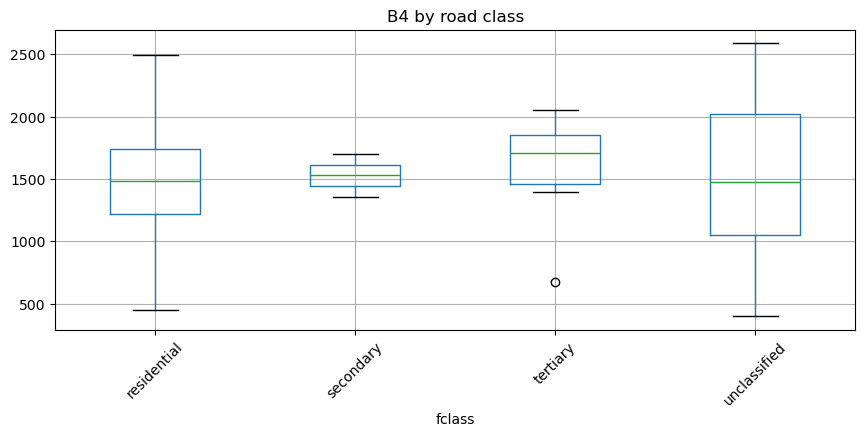

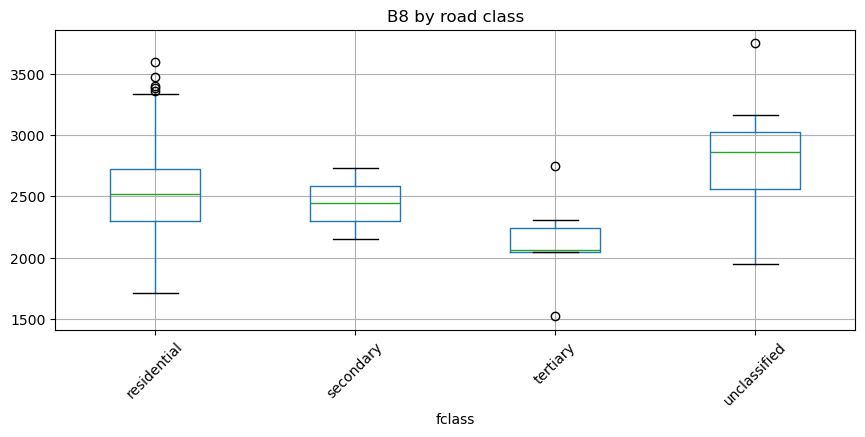

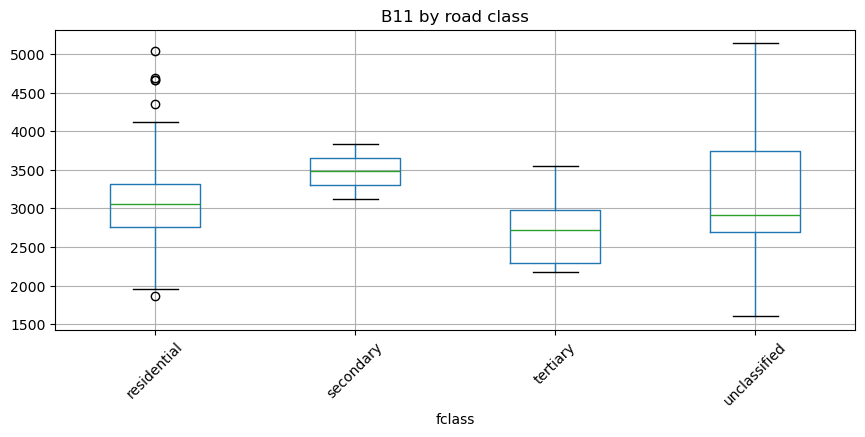

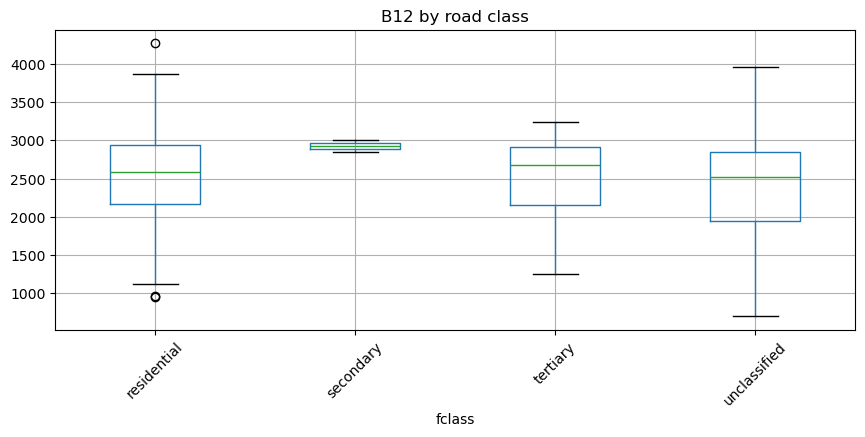

In [65]:
import matplotlib.pyplot as plt

features = ["NDVI","NDMI","NDBI","NDWI","BSI","B2","B3","B4","B8","B11","B12"]

for feat in features:
    df.boxplot(column=feat, by="fclass", figsize=(10,4), rot=45)
    plt.title(f"{feat} by road class")
    plt.suptitle("")
    plt.show()


In [66]:
from scipy.stats import ks_2samp

results = []
for feat in ["NDVI","NDMI","NDBI","NDWI","BSI"]:
    u = df[df["fclass"]=="unclassified"][feat].dropna()
    for cls in ["residential","tertiary","secondary","primary"]:
        c = df[df["fclass"]==cls][feat].dropna()
        if len(u)>10 and len(c)>10:
            ks = ks_2samp(u, c)
            results.append({"feature": feat, "class": cls, "KS_stat": ks.statistic, "p_value": ks.pvalue})

pd.DataFrame(results).sort_values(["feature","KS_stat"], ascending=[True, False])


,feature,class,KS_stat,p_value
4,BSI,residential,0.177035,0.808039
2,NDBI,residential,0.158218,0.895046
1,NDMI,residential,0.158218,0.895046
0,NDVI,residential,0.192780,0.720432
3,NDWI,residential,0.260753,0.358122
